In [1]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

sim_name = f"SunMod_1k"
# sim_name = f"SunMod_2k"
sim_folder = f"sim_output/{sim_name}"

fig_folder = f"figures_local/{sim_name}"
Cl_folder = f"Shared/Cls"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)


#! Broken halos: either snapshot info missing or anomalous number densities
exclude_nums = jnp.array([
    20,  # halo with missing/broken snapshot info
    23,  # halo with anomalous number densities (~0s on almost all pixels)
    24,  # anomalous "compactified into 1 cell" DM halo
    25,  # anomalous "compactified into 1 cell" DM halo
])
halo_nums = [x for x in range(1, 31) if x not in exclude_nums]


# Fermi-Dirac distribution assumption
dens_folder = f"sim_output/Dopri5_1k"
# note: total densities are computed for length 50 mass range
pix_dens_FD = jnp.load(f"{dens_folder}/pixel_densities.npy")[tuple(halo_nums),...]
tot_dens_FD = jnp.load(f"{dens_folder}/total_densities.npy")[tuple(halo_nums),...]

## Creating relative velocity vectors

In [14]:
v_unit = Params.km/Params.s
Sun_rel_CNB_vec = SimUtil.Galactic_velocity_to_Cartesian_vector(
    velocity=369.82, l=264.021, b=48.253)
Sun_rel_CNB_mag = jnp.linalg.norm(Sun_rel_CNB_vec, axis=-1)
# display in km/s
print(Sun_rel_CNB_vec)
print(Sun_rel_CNB_mag)

MW_rel_CNB_vec = SimUtil.Galactic_velocity_to_Cartesian_vector(
    velocity=565, l=265.76, b=28.38)
MW_rel_CNB_mag = jnp.linalg.norm(MW_rel_CNB_vec, axis=-1)
# display in km/s
print(MW_rel_CNB_vec)
print(MW_rel_CNB_mag)

def add_vels_spec_rel(v1, v2):
    return (v1 + v2)/(1 + v1*v2)

Sun_rel_MW_vec = add_vels_spec_rel(
    Sun_rel_CNB_vec*v_unit, -MW_rel_CNB_vec*v_unit)
Sun_rel_MW_mag = jnp.linalg.norm(Sun_rel_MW_vec, axis=-1)
print(Sun_rel_MW_vec/Sun_rel_MW_mag)
print(Sun_rel_MW_mag/v_unit)

[ -25.64952885 -244.90238947  275.91983202]
369.82
[ -36.75245455 -495.73471927  268.55417552]
565.0
[0.04420196 0.99859217 0.0293235 ]
251.18629660451225


## Creating integration steps for z, s and t
(all arrays go backwards in time)

In [6]:
def z_at_age(age):
    
    # Function to calculate redshift for a given age of the universe
    def age_diff(z):
        return cosmo.age(z).to(apu.year).value - age
    
    # Use root_scalar to find the redshift that gives the specified age
    sol = root_scalar(
        age_diff, bracket=[0, 10], method='brentq', xtol=1e-12, rtol=1e-12)
    return sol.root


def get_redshift_array(days):

    # Today's date
    today = Time.now()
    
    # Calculate redshift for each day
    redshifts = jnp.zeros(days)
    age_today = cosmo.age(0).to(apu.year).value  # Age of the universe today
    for day in range(days):

        # Calculate the date for each day of the past year
        past_date = today - day*apu.day
        
        # Calculate the lookback time in years
        lookback_time = (today - past_date).to(apu.year).value
        
        # Calculate the age of the universe at this lookback time
        age_of_universe_then = age_today - lookback_time
        
        # Find the redshift corresponding to this age of the universe
        redshift = z_at_age(age_of_universe_then)
        
        # Store the redshift value in the array
        redshifts = redshifts.at[day].set(redshift)
    
    return redshifts


def s_of_z(z, args):
    """
    Convert redshift to time variable s with eqn. 4.1 in Mertsch et al.
    (2020), keeping only Omega_M and Omega_L in the Hubble eqn. for H(z).

    Args:
        z (float): redshift

    Returns:
        float: time variable s (in [seconds] if 1/H0 factor is included)
    """    

    def s_integrand(z):        

        # We need value of H0 in units of 1/s.
        H0_val = args.H0/(1/args.s)
        a_dot = np.sqrt(args.Omega_M*(1.+z)**3 + args.Omega_L)/(1.+z)*H0_val
        s_int = 1./a_dot

        return s_int

    s_of_z, _ = quad(s_integrand, 0., z)

    return jnp.float64(s_of_z)


# Function to generate t_int_steps using Astropy
def generate_t_int_steps(z_int_steps):
    # Convert z_int_steps to a numpy array if it's not already
    z_int_steps_np = np.array(z_int_steps)
    
    # Calculate lookback times using Astropy
    t_int_steps_astropy = cosmo.lookback_time(z_int_steps_np)
    
    # Convert to seconds and then to a JAX array
    t_int_steps = jnp.array(t_int_steps_astropy.to(apu.s).value)
    
    return t_int_steps


# 2 years plus additional day, s.t. integration routine can pick 2nd last
# (see notes in backtrack_1_neutrino function)
days = (365*2)+1

# Get the redshift array for these (past) days
z_int_steps_2years = get_redshift_array(days)

# Convert to integration variable s
s_int_steps_2years = jnp.array(
    [s_of_z(z, Params()) for z in z_int_steps_2years])

# Convert to "physical" time in seconds
t_int_steps_2years = generate_t_int_steps(z_int_steps_2years)

jnp.save(f"{sim_folder}/z_int_steps_2years.npy", z_int_steps_2years)
jnp.save(f"{sim_folder}/s_int_steps_2years.npy", s_int_steps_2years)
jnp.save(f"{sim_folder}/t_int_steps_2years.npy", t_int_steps_2years)

## Earth's orbit from McCabe (2013)
(all arrays go forward in time)

### Functions and validations

In [7]:
### =========== ###
### Computing n ###
### =========== ###

year = 2023
fractional_days = SimUtil.calculate_fractional_day_numbers(year)
print(f"{len(fractional_days)} days for year {year}")

# Verify the example given (31st January 2009)
verification_date = datetime(2009, 1, 31)
Y, M, D = verification_date.year, verification_date.month, verification_date.day
Y_tilde = Y - 1 if M <= 2 else Y
M_tilde = M + 12 if M <= 2 else M
n_verification = np.floor(365.25 * Y_tilde) + np.floor(30.61 * (M_tilde + 1)) + D - 730563.5
print(f"\nVerification for 31st January 2009:")
print(f"Calculated n: {n_verification}")
print(f"Expected n: 3318.25 (at 6 p.m. GMT, our result is for 0:00 AM GMT)")


### ================ ###
### Ecliptic vectors ###
### ================ ###

eps_vectors = SimUtil.calculate_average_ecliptic_vectors(year)

print(f"Average ecliptic unit vectors for {year}:")
print(f"  ϵ_x = {eps_vectors[0]}")
print(f"  ϵ_y = {eps_vectors[1]}")

# Verify that the vectors are unit vectors
eps_x_magnitude = np.linalg.norm(eps_vectors[0])
eps_y_magnitude = np.linalg.norm(eps_vectors[1])
print(f"\nVerification:")
print(f"Magnitude of average ϵ_x: {eps_x_magnitude:.10f}")
print(f"Magnitude of average ϵ_y: {eps_y_magnitude:.10f}")

# Check orthogonality
dot_product = np.dot(eps_vectors[0], eps_vectors[1])
print(f"Dot product of ϵ_x and ϵ_y: {dot_product:.10f}")


### =============== ###
### Earth positions ###
### =============== ###

earth_positions = SimUtil.calculate_earth_position(year)

# Verify the magnitude of the position vector (should be close to 1 AU)
first_day = earth_positions[0]
position_magnitude = np.linalg.norm(first_day[1])
print(f"\nVerification for {first_day[0]}:")
print(f"Magnitude of position vector: {position_magnitude:.10f} AU")

365 days for year 2023

Verification for 31st January 2009:
Calculated n: 3317.5
Expected n: 3318.25 (at 6 p.m. GMT, our result is for 0:00 AM GMT)
Average ecliptic unit vectors for 2023:
  ϵ_x = [ 0.04918127 -0.49473286  0.86765235]
  ϵ_y = [0.99411415 0.10820555 0.00534915]

Verification:
Magnitude of average ϵ_x: 1.0000000000
Magnitude of average ϵ_y: 1.0000000000
Dot product of ϵ_x and ϵ_y: 0.0000001537

Verification for 2023-01-01:
Magnitude of position vector: 0.9833126525 AU


### Plots and comparisons

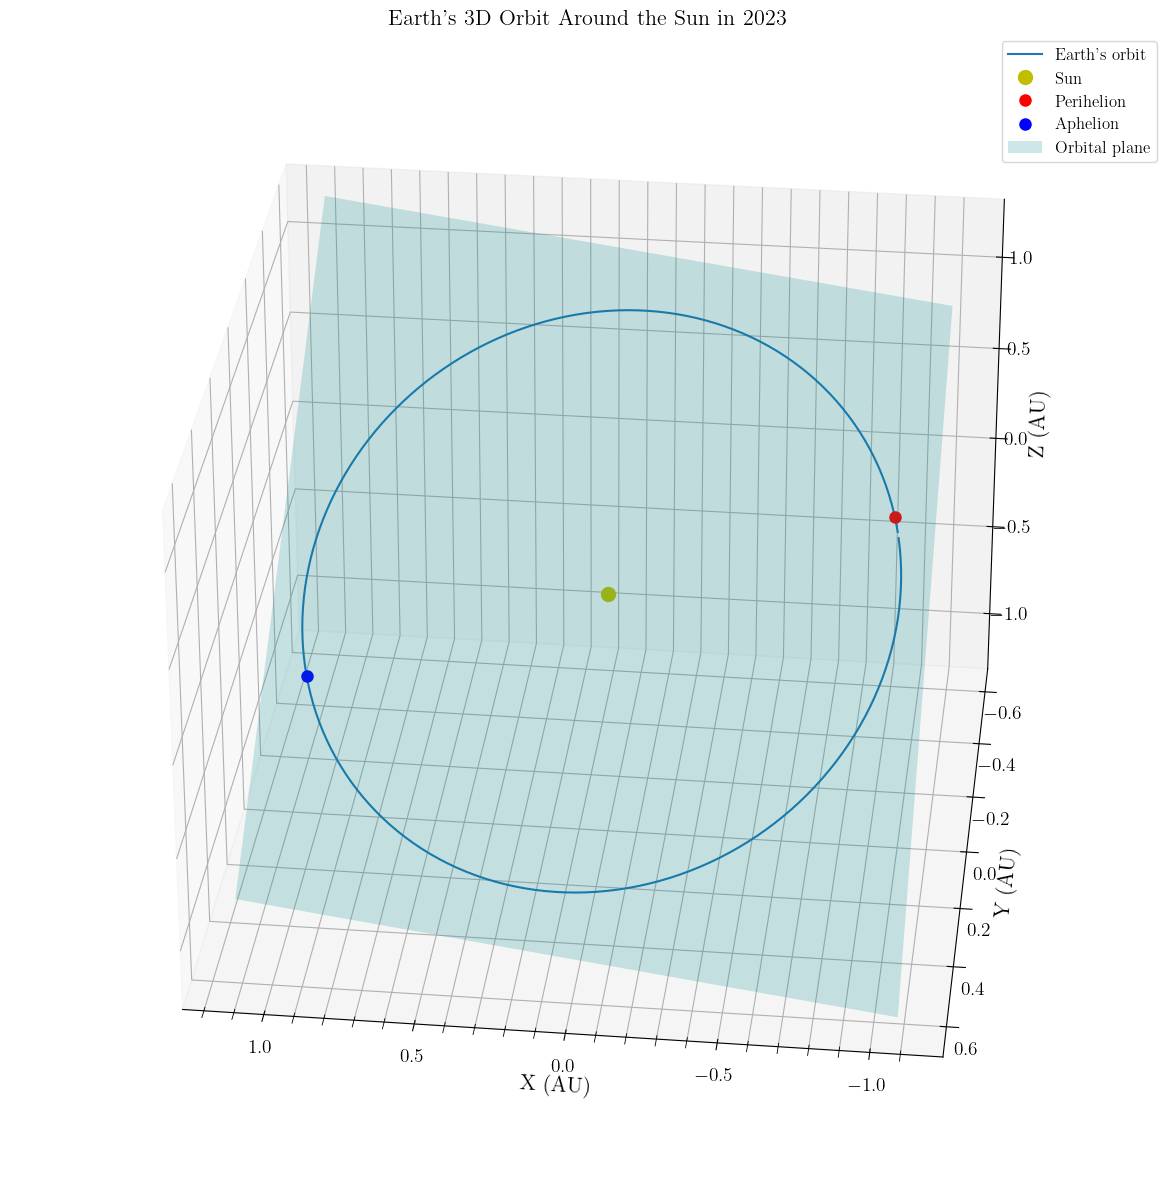

Elevation angle for top-down view: 29.81 degrees
Azimuth angle for top-down view: 96.39 degrees
Perihelion (closest to Sun): 2023-01-04, distance: 0.983290 AU
Aphelion (farthest from Sun): 2023-07-06, distance: 1.016710 AU


In [10]:
def plot_earth_trajectory_3d(year):
    earth_positions = SimUtil.calculate_earth_position(year)
    
    # Extract x, y, and z coordinates
    x = [pos[0] for _, pos in earth_positions]
    y = [pos[1] for _, pos in earth_positions]
    z = [pos[2] for _, pos in earth_positions]
    
    # Calculate distances from Sun
    distances = [np.linalg.norm(pos) for _, pos in earth_positions]
    
    # Find min and max distances
    min_dist_index = np.argmin(distances)
    max_dist_index = np.argmax(distances)
    
    # Create the 3D plot
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the orbit
    ax.plot(x, y, z, label='Earth\'s orbit')
    ax.plot([0], [0], [0], 'yo', markersize=10, label='Sun')
    ax.plot([x[min_dist_index]], [y[min_dist_index]], [z[min_dist_index]], 'ro', markersize=8, label='Perihelion')
    ax.plot([x[max_dist_index]], [y[max_dist_index]], [z[max_dist_index]], 'bo', markersize=8, label='Aphelion')
    
    # Find the normal vector to the orbital plane
    orbital_plane_normal = np.cross([x[0], y[0], z[0]], [x[len(x)//2], y[len(y)//2], z[len(z)//2]])
    orbital_plane_normal = orbital_plane_normal / np.linalg.norm(orbital_plane_normal)
    
    # Create a mesh for the orbital plane
    xx, yy = np.meshgrid(np.linspace(min(x)-0.1, max(x)+0.1, 10),
                         np.linspace(min(y)-0.1, max(y)+0.1, 10))
    d = -orbital_plane_normal[0]*x[0] - orbital_plane_normal[1]*y[0] - orbital_plane_normal[2]*z[0]
    zz = (-orbital_plane_normal[0] * xx - orbital_plane_normal[1] * yy - d) * 1. / orbital_plane_normal[2]
    
    # Plot the orbital plane
    ax.plot_surface(xx, yy, zz, alpha=0.2, color='cyan', label='Orbital plane')
    
    # Set labels and title
    ax.set_xlabel('X (AU)')
    ax.set_ylabel('Y (AU)')
    ax.set_zlabel('Z (AU)')
    ax.set_title(f"Earth's 3D Orbit Around the Sun in {year}")
    
    # Add legend
    ax.legend()
    
    # Calculate elevation and azimuth for top-down view
    elevation = np.arctan2(orbital_plane_normal[2], np.sqrt(orbital_plane_normal[0]**2 + orbital_plane_normal[1]**2))
    azimuth = np.arctan2(orbital_plane_normal[1], orbital_plane_normal[0])
    
    # Convert to degrees
    elev_deg = np.degrees(elevation)
    azim_deg = np.degrees(azimuth)
    
    # Set the view to top-down
    ax.view_init(elev=elev_deg, azim=azim_deg)
    # ax.view_init(elev=elev_deg-20, azim=azim_deg+70)
    
    plt.show()
    

    print(f"Elevation angle for top-down view: {elev_deg:.2f} degrees")
    print(f"Azimuth angle for top-down view: {azim_deg:.2f} degrees")
    print(f"Perihelion (closest to Sun): {earth_positions[min_dist_index][0]}, distance: {distances[min_dist_index]:.6f} AU")
    print(f"Aphelion (farthest from Sun): {earth_positions[max_dist_index][0]}, distance: {distances[max_dist_index]:.6f} AU")


plot_earth_trajectory_3d(year)

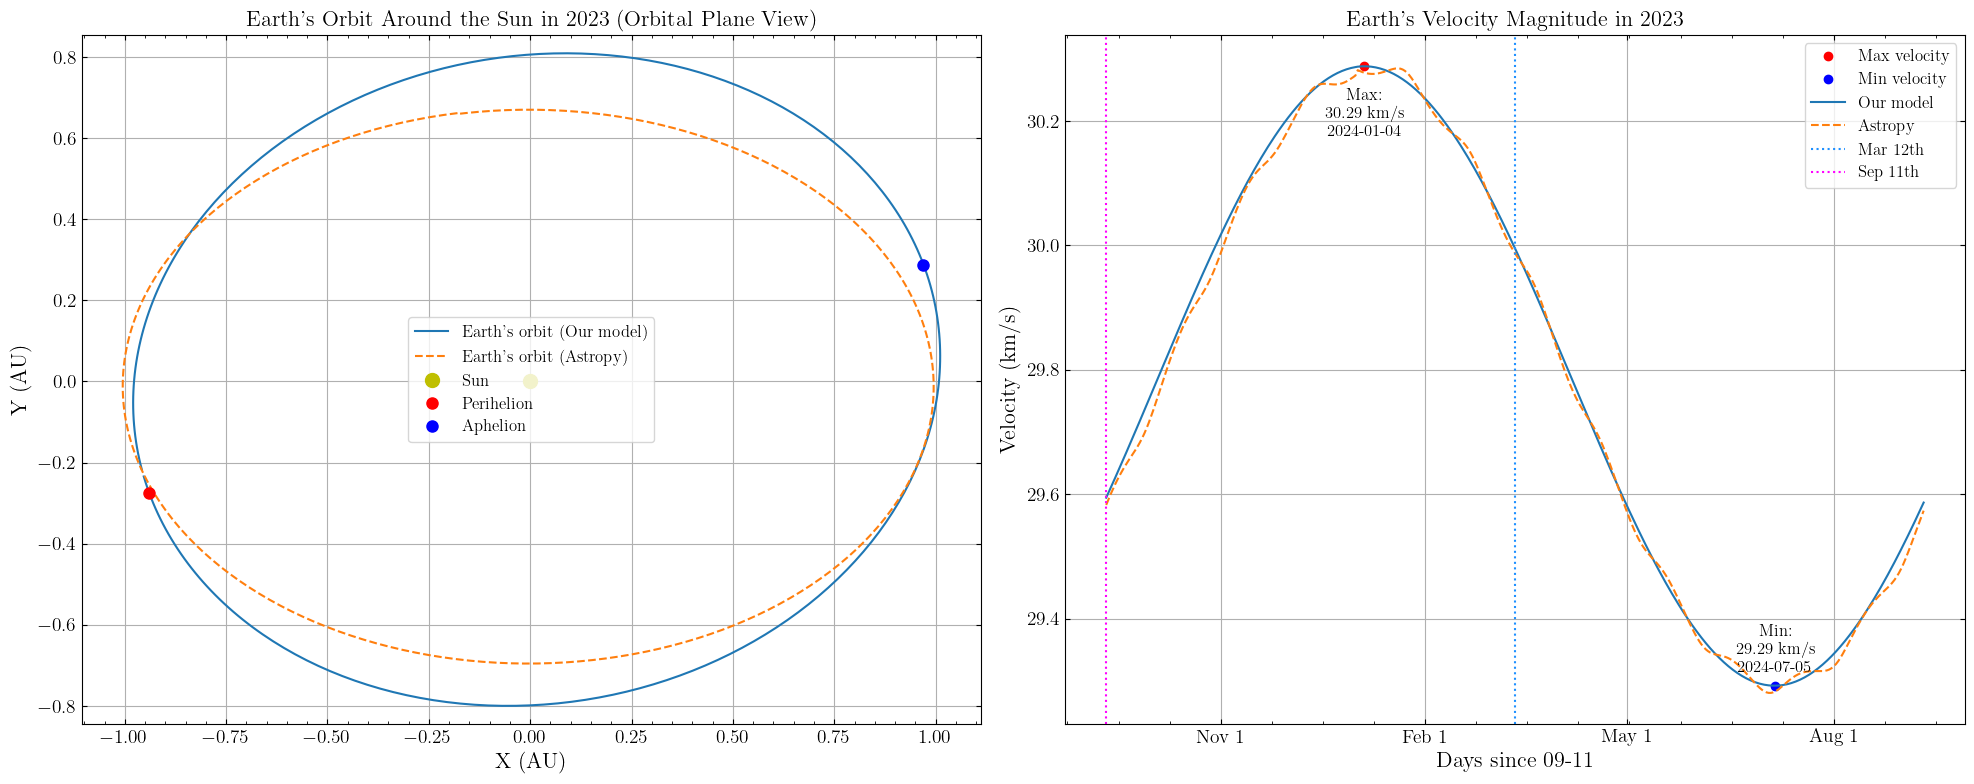

Our model - Maximum velocity: 30.29 km/s on 2024-01-04
Our model - Minimum velocity: 29.29 km/s on 2024-07-05
Astropy - Maximum velocity: 30.28 km/s
Astropy - Minimum velocity: 29.28 km/s


In [12]:
def get_astropy_earth_data(jd_times):
    """
    Get Earth's positions and velocities using Astropy for the given Julian dates.
    
    Parameters:
    -----------
    jd_times : array-like
        Array of Julian dates for which to calculate Earth's position and velocity
    
    Returns:
    --------
    tuple(list, list):
        - List of position vectors in AU
        - List of velocity vectors in km/s
    """
    positions = []
    velocities = []
    
    for jd in jd_times:
        # Get Earth's position and velocity from Astropy
        pos, vel = get_body_barycentric_posvel('earth', Time(jd, format='jd'))
        
        # Convert position to AU (it's already in AU)
        position = [pos.x.value, pos.y.value, pos.z.value]
        
        # Convert velocity to km/s (from AU/day)
        # 1 AU/day = 1731.45683633 km/s
        velocity = [
            vel.x.value * 1731.45683633,
            vel.y.value * 1731.45683633,
            vel.z.value * 1731.45683633
        ]
        
        positions.append(position)
        velocities.append(velocity)
    
    return positions, velocities


def rotate_to_orbital_plane(positions):
    """
    Rotate 3D position vectors to align with Earth's orbital plane.
    Earth's orbital plane is tilted by about 23.44° relative to the ecliptic plane.
    
    Parameters:
    -----------
    positions : list of lists
        List of [x, y, z] position vectors in the original coordinate system
    
    Returns:
    --------
    list:
        List of rotated [x, y, z] vectors where z approximately 0 (in orbital plane)
    """
    # Earth's orbital plane tilt (obliquity) in radians
    epsilon = np.radians(23.44)
    
    # Rotation matrix around x-axis to align with orbital plane
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(epsilon), -np.sin(epsilon)],
        [0, np.sin(epsilon), np.cos(epsilon)]
    ])
    
    # Convert positions to numpy array for easier manipulation
    pos_array = np.array(positions)
    
    # Apply rotation to all positions
    rotated_positions = np.dot(pos_array, Rx.T)
    
    # Convert back to list format
    return rotated_positions.tolist()


def plot_earth_trajectory_and_velocity(year, start_date_str='09-11'):
    """
    Plot Earth's 2D trajectory (in orbital plane) and velocity magnitude side by side, 
    comparing with Astropy data. The velocity plot's x-axis starts from the specified date.
    """
    # Convert start_date_str to datetime object
    start_date = datetime.strptime(f"{year}-{start_date_str}", '%Y-%m-%d')
    
    # Calculate the day of the year for the start date
    start_day_of_year = start_date.timetuple().tm_yday

    # Calculate Earth's positions and velocities using our model
    earth_positions = SimUtil.calculate_earth_position(year)
    earth_velocities = SimUtil.calculate_earth_velocity(year)
    
    # Generate time points for one year
    num_points = 365
    times = np.linspace(0, Params.yr, num_points)
    jd_times = Time(f'{year}-01-01').jd + times / Params.yr * 365.25
    
    # Get Astropy data for comparison
    astropy_positions, astropy_velocities = get_astropy_earth_data(jd_times)
    
    # Rotate positions to orbital plane view
    positions = [pos for _, pos in earth_positions]
    rotated_positions = rotate_to_orbital_plane(positions)
    rotated_astropy_positions = rotate_to_orbital_plane(astropy_positions)
    
    # Extract data
    x = [pos[0] for pos in rotated_positions]
    y = [pos[1] for pos in rotated_positions]
    x_astropy = [pos[0] for pos in rotated_astropy_positions]
    y_astropy = [pos[1] for pos in rotated_astropy_positions]
    dates = [datetime(year, 1, 1) + timedelta(days=i) for i in range(num_points)]
    velocities = [np.linalg.norm(vel) for _, vel in earth_velocities]
    astropy_velocities_mag = [np.linalg.norm(vel) for vel in astropy_velocities]

    # Create the figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 2D trajectory in orbital plane (left panel)
    ax1.plot(x, y, label="Earth's orbit (Our model)")
    ax1.plot(x_astropy, y_astropy, '--', label="Earth's orbit (Astropy)")
    ax1.plot(0, 0, 'yo', markersize=10, label='Sun')
    
    # Mark perihelion and aphelion
    min_dist_index = np.argmin([np.linalg.norm(pos) for pos in rotated_positions])
    max_dist_index = np.argmax([np.linalg.norm(pos) for pos in rotated_positions])
    ax1.plot(x[min_dist_index], y[min_dist_index], 'ro', markersize=8, label='Perihelion')
    ax1.plot(x[max_dist_index], y[max_dist_index], 'bo', markersize=8, label='Aphelion')
    
    ax1.set_title(f"Earth's Orbit Around the Sun in {year} (Orbital Plane View)")
    ax1.set_xlabel('X (AU)')
    ax1.set_ylabel('Y (AU)')
    ax1.legend()
    ax1.grid(True)
    ax1.axis('equal')
    
    # Plot velocity magnitude (right panel)
    # Shift days to start from the specified date
    shifted_days = [(d - start_date).days % 365 + 1 for d in dates]
    sorted_indices = np.argsort(shifted_days)
    shifted_days = [shifted_days[i] for i in sorted_indices]
    velocities = [velocities[i] for i in sorted_indices]
    astropy_velocities_mag = [astropy_velocities_mag[i] for i in sorted_indices]

    # After sorting velocities and before plotting in ax2
    max_vel_index = np.argmax(velocities)
    min_vel_index = np.argmin(velocities)

    # After plotting velocities in ax2
    ax2.plot(shifted_days[max_vel_index], velocities[max_vel_index], 'ro', label='Max velocity')
    ax2.plot(shifted_days[min_vel_index], velocities[min_vel_index], 'bo', label='Min velocity')

    # Calculate the actual dates for max and min velocities
    max_date = (start_date + timedelta(days=shifted_days[max_vel_index] - 1)).strftime("%Y-%m-%d")
    min_date = (start_date + timedelta(days=shifted_days[min_vel_index] - 1)).strftime("%Y-%m-%d")

    ax2.annotate(
        f'Max: \n{velocities[max_vel_index]:.2f} km/s\n{max_date}',
        (shifted_days[max_vel_index], velocities[max_vel_index]), 
        textcoords="offset points", xytext=(0,-50), ha='center')
    ax2.annotate(
        f'Min: \n{velocities[min_vel_index]:.2f} km/s\n{min_date}',
        (shifted_days[min_vel_index], velocities[min_vel_index]), 
        textcoords="offset points", xytext=(0,+10), ha='center')

    ax2.plot(shifted_days, velocities, label='Our model')
    ax2.plot(shifted_days, astropy_velocities_mag, '--', label='Astropy')
    ax2.set_title(f"Earth's Velocity Magnitude in {year}")
    ax2.set_xlabel("Days since " + start_date_str)
    ax2.set_ylabel("Velocity (km/s)")
    ax2.grid(True)
    
    # Calculate tick positions and labels
    tick_dates = [datetime_date(2000, 11, 1), datetime_date(2000, 2, 1), 
                datetime_date(2000, 5, 1), datetime_date(2000, 8, 1)]
    tick_days = [(d - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1 for d in tick_dates]
    tick_labels = ['Nov 1', 'Feb 1', 'May 1', 'Aug 1']
    ax2.set_xticks(tick_days)
    ax2.set_xticklabels(tick_labels)

    # Add vertical lines for March 12th and September 11th
    march_12 = (datetime_date(2000, 3, 12) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
    sept_11 = (datetime_date(2000, 9, 11) - datetime_date(2000, start_date.month, start_date.day)).days % 365 + 1
    ax2.axvline(x=march_12, color='dodgerblue', linestyle=':', label='Mar 12th')
    ax2.axvline(x=sept_11, color='magenta', linestyle=':', label='Sep 11th')

    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    # Print velocity statistics
    print(f"Our model - Maximum velocity: {velocities[max_vel_index]:.2f} km/s on {max_date}")
    print(f"Our model - Minimum velocity: {velocities[min_vel_index]:.2f} km/s on {min_date}")
    print(f"Astropy - Maximum velocity: {max(astropy_velocities_mag):.2f} km/s")
    print(f"Astropy - Minimum velocity: {min(astropy_velocities_mag):.2f} km/s")


plot_earth_trajectory_and_velocity(year, start_date_str='09-11')

### Animations of Sun-Earth dynamics in simulation

In [ ]:
def animate_sun_trajectory(
        sun_positions, sun_velocities, interval=50, subsample=1, save_path=None, freeze_duration=2, elev=30, azim=-60, max_extent=None, dpi=50):
    # Subsample the sun positions and velocities if needed
    positions = sun_positions[::subsample]
    velocities = sun_velocities[::subsample]

    # Calculate the maximum extent of the trajectory
    if max_extent is None:
        max_extent = np.max(np.abs(positions))

    # Scale factor for velocity arrows
    vel_scale = max_extent / np.max(np.linalg.norm(velocities, axis=1)) * 0.2

    # Create a figure with adjusted size
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Adjust the axes position to fill more of the figure
    ax.set_position([0.1, 0.1, 0.8, 0.8])

    # Set axis limits
    ax.set_xlim(-max_extent, max_extent)
    ax.set_ylim(-max_extent, max_extent)
    ax.set_zlim(-max_extent, max_extent)

    # Set labels with smaller font size
    ax.set_xlabel('X (Earth-GC direction)', fontsize=8)
    ax.set_ylabel('Y', fontsize=8)
    ax.set_zlabel('Z', fontsize=8)
    ax.set_title("Sun's Trajectory Relative to Earth (Earth-GC Frame)", fontsize=10)

    # Reduce tick label size
    ax.tick_params(axis='both', which='major', labelsize=6)

    # Plot Earth as a blue sphere at the center
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    earth_radius = 0.05 * max_extent
    ex = earth_radius * np.outer(np.cos(u), np.sin(v))
    ey = earth_radius * np.outer(np.sin(u), np.sin(v))
    ez = earth_radius * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(ex, ey, ez, color='blue', alpha=0.7)

    # Add Earth-GC line (x-axis)
    ax.plot([-max_extent, max_extent], [0, 0], [0, 0], color='red', linestyle='--', label='Earth-GC line')

    # Plot the ecliptic plane
    xx, yy = np.meshgrid(np.linspace(-max_extent, max_extent, 10), np.linspace(-max_extent, max_extent, 10))
    zz = np.zeros_like(xx)
    ax.plot_surface(xx, yy, zz, alpha=0.2, color='cyan')

    # Find the point with maximum z-coordinate
    max_z_index = np.argmax(positions[:, 2])
    max_z_point = positions[max_z_index]

    # Plot line from origin to max_z_point
    ax.plot([0, max_z_point[0]], [0, max_z_point[1]], [0, max_z_point[2]], color='green', linestyle=':', label='Max height line')

    # Initialize the sun trajectory line and point
    line, = ax.plot([], [], [], color='yellow', label='Sun trajectory')
    point, = ax.plot([], [], [], 'yo', markersize=6, label='Sun')

    # Initialize the velocity arrow (we'll update its data in each frame)
    quiver = ax.quiver(0, 0, 0, 0, 0, 0, color='orange', label='Sun velocity (GC frame)')

    # Set the view angle
    ax.view_init(elev=elev, azim=azim)

    # Ensure equal aspect ratio
    ax.set_box_aspect((1, 1, 1))

    # Reduce legend font size and move it to a less obtrusive position
    ax.legend(fontsize=6, loc='upper right', bbox_to_anchor=(1, 1))

    # Adjust layout
    plt.tight_layout()

    # Animation update function
    def update(frame):
        if frame < len(positions):
            line.set_data(positions[:frame, 0], positions[:frame, 1])
            line.set_3d_properties(positions[:frame, 2])
            point.set_data(positions[frame:frame+1, 0], positions[frame:frame+1, 1])
            point.set_3d_properties(positions[frame:frame+1, 2])
            
            # Update velocity arrow
            quiver.set_segments([[[positions[frame, 0], positions[frame, 1], positions[frame, 2]],
                                  [positions[frame, 0] + velocities[frame, 0] * vel_scale,
                                   positions[frame, 1] + velocities[frame, 1] * vel_scale,
                                   positions[frame, 2] + velocities[frame, 2] * vel_scale]]])
        else:
            # Freeze frame: show the complete trajectory
            line.set_data(positions[:, 0], positions[:, 1])
            line.set_3d_properties(positions[:, 2])
            point.set_data([], [])
            point.set_3d_properties([])
            quiver.set_segments([[[0, 0, 0], [0, 0, 0]]])  # Hide arrow in freeze frame

        return line, point, quiver

    # Calculate total frames (including freeze frames)
    total_frames = len(positions) + int(freeze_duration * 1000 / interval)

    # Create the animation
    anim = FuncAnimation(fig, update, frames=total_frames, interval=interval, blit=False, repeat=False)

    if save_path:
        # Save the animation with higher DPI
        anim.save(save_path, writer='pillow', fps=1000//interval, dpi=dpi)
    else:
        # Show the plot
        plt.show()

    return anim


def SunEarthGC_frame_coords_local(year):
    """
    Calculate coordinates and velocities in a frame aligned with the Galactic Center,
    using get_body_barycentric_posvel for more accurate Earth velocities.
    """
    # Define the Galactic Center coordinates
    gc = SkyCoord(l=0*apu.degree, b=0*apu.degree, frame='galactic')
    
    # Sun's velocity w.r.t. CNB in galactic coordinates/frame (km/s)
    sun_vel_CNB = np.array([-0.06935679, -0.66222051, 0.74609224]) * 369.82

    # Sun's velocity w.r.t. MWGC in galactic coordinates/frame (km/s)
    sun_vel_MW = np.array([11.1029257, 250.8323298, 7.3656565])
    
    sun_vel_Gal = sun_vel_MW

    # Lists for Sun's positions and velocities, and Earth's velocities
    sun_positions = []
    sun_vels = []
    earth_vels = []
    
    # Loop backwards through each day of the year
    for day in range(365, 0, -1):  
        # Time object of current day at noon UTC
        time = Time(f'{year}-12-31 12:00:00') - (365-day)*apu.day
        
        # Get Earth's position and velocity using get_body_barycentric_posvel
        earth_pos, earth_vel = get_body_barycentric_posvel('earth', time)
        
        # Convert Earth's velocity from AU/day to km/s
        earth_vel_icrs = np.array([
            earth_vel.x.value,
            earth_vel.y.value,
            earth_vel.z.value
        ]) * 1731.45683633  # conversion factor from AU/day to km/s
        
        # Get Sun's position in GCRS coordinates (relative to Earth) in km
        sun_gcrs = SkyCoord(
            get_body_barycentric('sun', time), 
            frame='icrs').transform_to(GCRS(obstime=time))
        sun_vector = sun_gcrs.cartesian.xyz.to(apu.km).value
        
        # Transform the Galactic Center to GCRS
        gc_gcrs = gc.transform_to(GCRS(obstime=time))
        
        # Calculate the unit vector pointing from Earth to Galactic Center
        gc_vector = gc_gcrs.cartesian.xyz.value
        gc_unit_vector = gc_vector / np.linalg.norm(gc_vector)
        
        # Define the new coordinate system
        x_axis = gc_unit_vector
        z_axis = np.cross(x_axis, [0, 0, 1])
        z_axis = z_axis / np.linalg.norm(z_axis)
        y_axis = np.cross(z_axis, x_axis)
        
        # Create rotation matrix
        rotation_matrix = np.column_stack((x_axis, y_axis, z_axis))
        
        # Rotate Sun's position and velocity into new coordinate system
        sun_rotated = np.dot(rotation_matrix.T, sun_vector)
        sun_vel_rotated = np.dot(rotation_matrix.T, sun_vel_Gal)
        
        # Rotate Earth's velocity into the new coordinate system (km/s)
        earth_vel_rotated = np.dot(rotation_matrix.T, earth_vel_icrs)
        
        # Calculate Earth's velocity relative to CMB in the rotated frame (km/s)
        earth_vel_rotated = sun_vel_rotated + earth_vel_rotated
        
        # Append the rotated position and velocities to the lists
        sun_positions.append(sun_rotated)
        sun_vels.append(sun_vel_rotated)
        earth_vels.append(earth_vel_rotated)
    
    # note: sun_positions: km units ; velocities: km/s units
    return np.array(sun_positions), np.array(sun_vels), np.array(earth_vels)


# Sun's trajectory animated in special Earth-GC frame for each day of year 2024
year = 2024
# sun_positions, sun_velocities, _ = SimPlot.SunEarthGC_frame_coords(year)
sun_positions, sun_velocities, _ = SunEarthGC_frame_coords_local(year)
animate_sun_trajectory(
    sun_positions, 
    sun_velocities,
    interval=50, 
    subsample=5, 
    save_path='sun_trajectory_animation_with_GC_vel_arrow.gif', 
    freeze_duration=0.01, 
    elev=20, 
    azim=170,
    dpi=300
)

## Methods & plots for Safdi et al. (2014)

### Methods & tests

#### Maxwell velocity distr. (SMH) integrating to 1

In [ ]:
def maxwell_f(v_mag, v_0, v_esc):

    mask = v_mag < v_esc
    f_v = jnp.where(
        mask, 
        jnp.power(jnp.pi*v_0**2, -3/2) * jnp.exp(-v_mag**2/v_0**2), 
        0.0)
    z = v_esc/v_0
    N_esc = jsp.special.erf(z) - 2/jnp.sqrt(jnp.pi)*z*jnp.exp(-z**2)
    f_v_normalized = f_v / N_esc

    return f_v_normalized

p_range = jnp.geomspace(0.001, 100, 10000)*Params.T_CNB
v_unit = Params.km/Params.s
# m_test = 0.35
m_test = 0.5
v_range = p_range / m_test

f_v_norm = maxwell_f(v_range, 220*v_unit, 550*v_unit)
f_int = trap(v_range**3*f_v_norm, x=jnp.log(v_range))
print(4*jnp.pi*f_int)

#### 1D (isotropic) integration of $f_{\rm FD}(\vec{v}_\nu)$

In [ ]:
m_nu = 0.35*Params.eV
p_range = jnp.geomspace(0.01, 10, 1000)*Params.T_CNB
v_range = p_range / m_nu


def fermi_dirac_mom(p):
    return 1/(jnp.exp(p/Params.T_CNB)+1)

f_FD_p = fermi_dirac_mom(p_range)
f_int_p = trap(p_range**3*f_FD_p, x=jnp.log(p_range))
print(f"1D number density (p): {f_int_p/(2*jnp.pi**2)/Params.cm**-3:5f} cm^-3")


def fermi_dirac_vel(m, v):
    return m**3/(jnp.exp(m*v/Params.T_CNB)+1)

f_FD_v = fermi_dirac_vel(m_nu, v_range)

f_int_v = trap(v_range**3*f_FD_v, x=jnp.log(v_range))
print(f"1D number density (v): {f_int_v/(2*jnp.pi**2)/Params.cm**-3:5f} cm^-3")

#### 3D integration of $f_{\rm FD}(\vec{v}_\nu)$

In [ ]:
@jax.jit
def fermi_dirac_vel(m, v_x, v_y, v_z):
    v = jnp.sqrt(v_x**2 + v_y**2 + v_z**2)
    return m**3 / (jnp.exp(m*v/Params.T_CNB) + 1)

@jax.jit
def number_density_3d(m_nu, v_max):
    
    # We can use the (+/-) max velocity magnitudes to create the ranges for the 
    # x,y,z components, because accounting for the whole velocity sphere means 
    # that the extremes would be that e.g. the x-direction has the total 
    # (+ or -) value of the magnitude already, whereas y-, and z- are 0. And so 
    # for all the other extreme cases. Then the mesh grid accounts for all 
    # x,y,z combinations.
    mesh_num = 500
    mesh_v = jnp.linspace(-v_max, v_max, mesh_num)
    v_x, v_y, v_z = jnp.meshgrid(mesh_v, mesh_v, mesh_v, indexing='xy')

    f_FD_v = fermi_dirac_vel(m_nu, v_x, v_y, v_z)
    print(f_FD_v.shape)

    # Perform the 3D integration
    integral_over_z = trap(f_FD_v, mesh_v, axis=-1)
    integral_over_yz = trap(integral_over_z, mesh_v, axis=-1)
    integral_over_xyz = trap(integral_over_yz, mesh_v, axis=-1)
    
    return integral_over_xyz / (2*jnp.pi)**3
    

# Parameters
m_nu = 0.35*Params.eV
v_max = 100*Params.T_CNB / m_nu

# Compute number density using 3D integration
n_3d = number_density_3d(m_nu, v_max)
print(f"3D number density: {n_3d/Params.cm**-3:5f} cm^-3")
n_3d /= Params.N0
print(f"normalised: {n_3d}")
#? so by density "rho" they actually mean the number density?

Adding any constant velocities here, as e.g. $f_{\rm FD}(\vec{v}_\nu + \vec{v}_{\rm CMB} + \vec{V}_\oplus(t))$, will technically not affect the number density, as the integration over each axis ideally goes from -inf to inf. So shifting the v_range will not affect anything. Of course that's hard to demonstrate numerically though, as it would require very large mesh range and dense sampling.

See cell below for attempt.

In [ ]:
@jax.jit
def fermi_dirac_vel(m, v_x, v_y, v_z):
    v = jnp.sqrt(v_x**2 + v_y**2 + v_z**2)
    return m**3 / (jnp.exp(m*v/Params.T_CNB) + 1)

@jax.jit
def number_density_3d(t_index, m_nu, v_max):

    mesh_num = 500
    mesh_v = jnp.linspace(-v_max, v_max, mesh_num)
    v_x, v_y, v_z = jnp.meshgrid(mesh_v, mesh_v, mesh_v, indexing='xy')

    # Add constant velocities
    v_x += v_CNB[0] + earth_velocities[t_index,0]
    v_y += v_CNB[1] + earth_velocities[t_index,1]
    v_z += v_CNB[2] + earth_velocities[t_index,2]

    f_FD_v = fermi_dirac_vel(m_nu, v_x, v_y, v_z)

    # Perform the 3D integration
    integral_over_z = trap(f_FD_v, mesh_v, axis=-1)
    integral_over_yz = trap(integral_over_z, mesh_v, axis=-1)
    integral_over_xyz = trap(integral_over_yz, mesh_v, axis=-1)
    
    return integral_over_xyz / (2*jnp.pi)**3
    

# Parameters
m_nu = 0.35*Params.eV
v_max = 100*Params.T_CNB / m_nu

# Compute number density using 3D integration
for t_index in (1, 45, 90, 135, 180, 225, 270):
    n_3d = number_density_3d(t_index, m_nu, v_max)
    print(f"3D n_nu (day {t_index}): {n_3d/Params.cm**-3:5f} cm^-3 (norm: {n_3d/Params.N0:6f})")

### Plots: bound & unbound individually, and combined

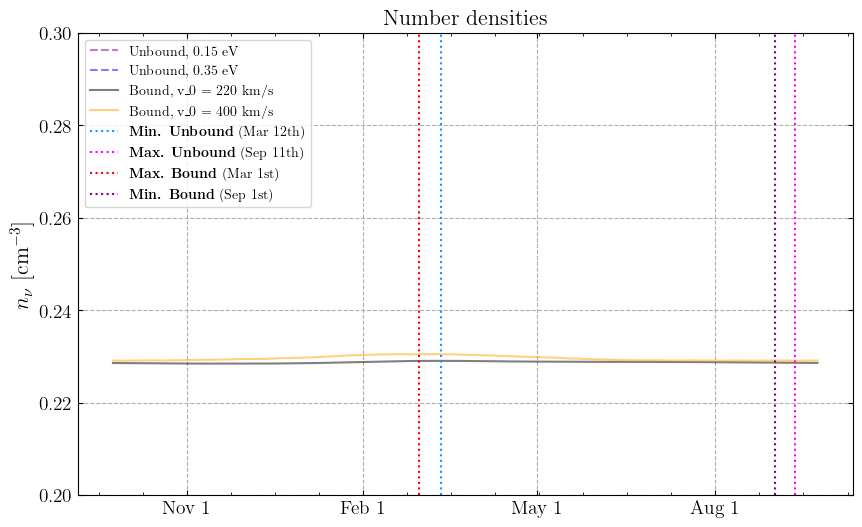

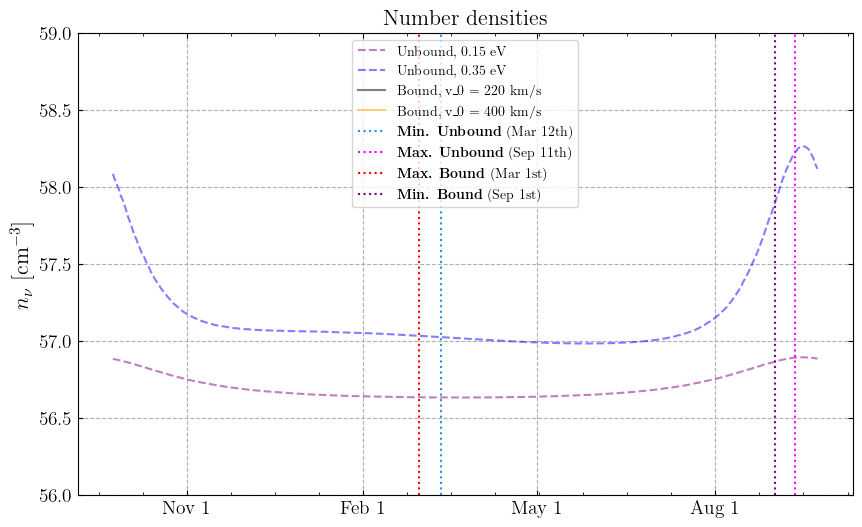

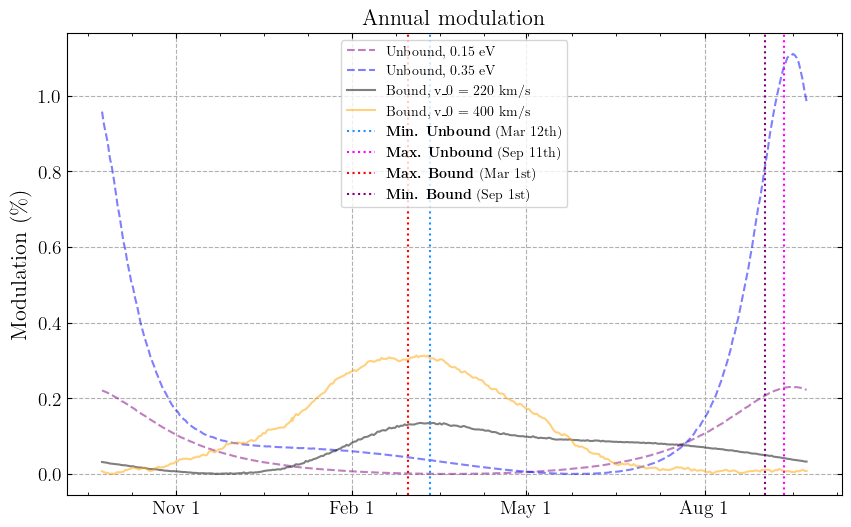

In [3]:
# Safdi+ light and heavy mass
m_l = 0.15*Params.eV
m_h = 0.35*Params.eV

# Custom light and heavy mass
# m_l = 0.05*Params.eV
# m_h = 0.2*Params.eV

cases = [
    (m_l, False, 220.0*Params.km/Params.s, f'Unbound, {m_l} eV', 'dashed', 'purple', 0.5),
    (m_h, False, 220.0*Params.km/Params.s, f'Unbound, {m_h} eV', 'dashed', 'blue', 0.5),
    (m_h, True, 220.0*Params.km/Params.s, 'Bound, v_0 = 220 km/s', 'solid', 'black', 0.5),
    (m_h, True, 400.0*Params.km/Params.s, 'Bound, v_0 = 400 km/s', 'solid', 'orange', 0.5)
]

# Original relative velocities
# density_arrays = {
#     f"annual_densities_{m_l}eV_unbound": jnp.load(f"{sim_folder}/annual_densities_{m_l}eV_unbound.npy"),
#     f"annual_densities_{m_h}eV_unbound": jnp.load(f"{sim_folder}/annual_densities_{m_h}eV_unbound.npy"),
#     f"annual_densities_220.0kms_{m_h}eV_bound": jnp.load(f"{sim_folder}/annual_densities_220.0kms_{m_h}eV_bound.npy"),
#     f"annual_densities_400.0kms_{m_h}eV_bound": jnp.load(f"{sim_folder}/annual_densities_400.0kms_{m_h}eV_bound.npy")
# }

# Exchanged relative velocities for bound <-> unbound, i.e. v_Sun <-> v_CNB
# density_arrays = {
#     f"annual_densities_{m_l}eV_unbound": jnp.load(f"{sim_folder}/annual_densities_{m_l}eV_unbound_v_switch.npy"),
#     f"annual_densities_{m_h}eV_unbound": jnp.load(f"{sim_folder}/annual_densities_{m_h}eV_unbound_v_switch.npy"),
#     f"annual_densities_220.0kms_{m_h}eV_bound": jnp.load(f"{sim_folder}/annual_densities_220.0kms_{m_h}eV_bound_v_switch.npy"),
#     f"annual_densities_400.0kms_{m_h}eV_bound": jnp.load(f"{sim_folder}/annual_densities_400.0kms_{m_h}eV_bound_v_switch.npy")
# }

# Vels switched and Msun / 1000
# density_arrays = {
#     f"annual_densities_{m_l}eV_unbound": jnp.load(f"{sim_folder}/annual_densities_{m_l}eV_unbound_v_switch_div1000.npy"),
#     f"annual_densities_{m_h}eV_unbound": jnp.load(f"{sim_folder}/annual_densities_{m_h}eV_unbound_v_switch_div1000.npy"),
#     f"annual_densities_220.0kms_{m_h}eV_bound": jnp.load(f"{sim_folder}/annual_densities_220.0kms_{m_h}eV_bound_v_switch_div1000.npy"),
#     f"annual_densities_400.0kms_{m_h}eV_bound": jnp.load(f"{sim_folder}/annual_densities_400.0kms_{m_h}eV_bound_v_switch_div1000.npy")
# }

# Vels switched and Msun / 1000
density_arrays = {
    f"annual_densities_{m_l}eV_unbound": jnp.load(f"{sim_folder}/annual_densities_{m_l}eV_unbound_v_fast.npy"),
    f"annual_densities_{m_h}eV_unbound": jnp.load(f"{sim_folder}/annual_densities_{m_h}eV_unbound_v_fast.npy"),
    f"annual_densities_220.0kms_{m_h}eV_bound": jnp.load(f"{sim_folder}/annual_densities_220.0kms_{m_h}eV_bound_v_fast.npy"),
    f"annual_densities_400.0kms_{m_h}eV_bound": jnp.load(f"{sim_folder}/annual_densities_400.0kms_{m_h}eV_bound_v_fast.npy")
}

SimPlot.plot_modulations_Safdi_arrays(
    "both", density_arrays, cases, fig_folder, start_date_str='09-23', 
    y_lims=(0.2, 0.3),
    mode="densities",
    # pdf_str=f"Safdi_densities_{m_l}eV_{m_h}eV_bound.pdf")
    # pdf_str=f"Safdi_densities_{m_l}eV_{m_h}eV_bound_v_switch.pdf")
    pdf_str=f"Safdi_densities_{m_l}eV_{m_h}eV_bound_v_fast.pdf")

SimPlot.plot_modulations_Safdi_arrays(
    "both", density_arrays, cases, fig_folder, start_date_str='09-23', 
    y_lims=(56.0, 59.0),
    mode="densities",
    # pdf_str=f"Safdi_densities_{m_l}eV_{m_h}eV_unbound.pdf")
    # pdf_str=f"Safdi_densities_{m_l}eV_{m_h}eV_unbound_v_switch.pdf")
    pdf_str=f"Safdi_densities_{m_l}eV_{m_h}eV_unbound_v_fast.pdf")

SimPlot.plot_modulations_Safdi_arrays(
    "both", density_arrays, cases, fig_folder, start_date_str='09-23', 
    y_lims=None,
    mode="modulation",
    # pdf_str=f"Safdi_modulation_{m_l}eV_{m_h}eV.pdf")
    # pdf_str=f"Safdi_modulation_{m_l}eV_{m_h}eV_v_switch.pdf")
    pdf_str=f"Safdi_modulation_{m_l}eV_{m_h}eV_v_fast.pdf")

## Percentages of bound vs. unbound CNB

### % via median method used in first paper

In [ ]:
# Escape momentum
x_i_Earth = jnp.array([8.127, 0., 0.])*Params.kpc
DM_sim_folder = f"sim_output/Dopri5_1k"
p_esc_arr, y_esc_arr = SimUtil.get_p_esc(
    DM_sim_folder, x_i_Earth, nu_m_picks, Params())
# print(p_esc_arr.shape)
# print(y_esc_arr)


# Neutrino velocities
halo_num = 10
DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)

# Sorted momenta arrays    
_, p_z0_DM_sim, p_z4_DM_sim, y_z0_DM_sim, _ = Utils.sim_vels_to_sorted_z0z4(
    DM_sim_vels, nu_m_picks, 
    merge_last_axes=False, args=Params())

# PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
# (halos, masses, Npix, p_num)

# Select most (likely) clustered ones
FD_z0_max = jnp.max(jnp.swapaxes(FD_vals_z0, -1, -2), axis=-1)
FD_median = jnp.median(FD_z0_max, axis=0)

# x-axis
p_z0_select = jnp.swapaxes(p_z0_DM_sim, -1, -2)[..., 0]
p_z0_median = jnp.median(p_z0_select, axis=0)

p_esc_med = jnp.median(p_esc_arr, axis=0)

n_bound_l = []
for mi, p_esc in enumerate(p_esc_med):

    p_z0_med_mi = p_z0_median[mi]
    FD_med_mi = FD_median[mi]

    # Compare momenta to escape momentum
    below_esc = (p_z0_med_mi < p_esc)

    # Select bound values and reshape
    x_bound = p_z0_med_mi[below_esc]
    y_bound = FD_med_mi[below_esc]

    # Compute integral for bound neutrinos
    n_bound = trap(x_bound**3*y_bound, jnp.log(x_bound), axis=-1)
    n_bound_l.append(n_bound)

n_bound = jnp.stack(n_bound_l)

# Compute total (normalization) integral
n_norm = trap(p_z0_median**3*FD_median, jnp.log(p_z0_median), axis=-1)

# Compute percentages
percentages = (n_bound / n_norm) * 100
print([f"{perc:.5f}" for perc in percentages])

['0.00646', '0.70802', '3.97164', '12.39122', '17.70188']


### % per halo, mass and pixels

In [ ]:
# Escape momentum
x_i_Earth = jnp.array([8.127, 0., 0.])*Params.kpc
DM_sim_folder = f"sim_output/Dopri5_1k"
p_esc_arr, y_esc_arr = SimUtil.get_p_esc(
    DM_sim_folder, x_i_Earth, nu_m_picks, Params())
# print(p_esc_arr.shape)
# print(y_esc_arr)


### =============== ###
### Index selection ###
### =============== ###

# Neutrino velocities
halo_num = 20
# DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)
DM_sim_vels = SimData.load_velocities(sim_dir=dens_folder, halo_num=halo_num)

# Sorted momenta arrays    
_, p_z0_DM_sim, p_z4_DM_sim, _, _ = Utils.sim_vels_to_sorted_z0z4(
    DM_sim_vels, nu_m_picks, 
    merge_last_axes=False, args=Params())

# PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
# (halos, masses, Npix, p_num)

h_dim, m_dim, p_dim, _ = p_z0_DM_sim.shape

n_bound_l = []
for hi in range(p_esc_arr.shape[0]):  # Loop over halos
    
    n_bound_masses_l = []
    
    for mi in range(p_esc_arr.shape[1]):  # Loop over masses

        p_z0_DM_sim_hi_mi = p_z0_DM_sim[hi, mi, ...]
        FD_vals_z0_hi_mi = FD_vals_z0[hi, mi, ...]
        p_esc_hi_mi = p_esc_arr[hi, mi]
        
        # Compare momenta to escape momentum
        # below_esc = (p_z0_DM_sim_hi_mi < p_esc_hi_mi)
        below_esc = (p_z0_DM_sim_hi_mi >= p_esc_hi_mi)
        
        # Select bound values and reshape
        x_bound = p_z0_DM_sim_hi_mi[below_esc].reshape(p_z0_DM_sim_hi_mi.shape[0], -1)
        y_bound = FD_vals_z0_hi_mi[below_esc].reshape(p_z0_DM_sim_hi_mi.shape[0], -1)
        
        # Compute integral for bound neutrinos
        n_bound = trap(x_bound**3*y_bound, jnp.log(x_bound), axis=-1)
        n_bound_masses_l.append(n_bound)
    
    n_bound_l.append(jnp.stack(n_bound_masses_l))

n_bound = jnp.stack(n_bound_l)  # Final shape: (n_halos, n_masses, n_pixels)
print(n_bound.shape)

# Compute total (normalization) integral
n_norm = trap(p_z0_DM_sim**3*FD_vals_z0, jnp.log(p_z0_DM_sim), axis=-1)

# Compute percentages
percentages_method_1 = (jnp.array(n_bound_l[:len(n_norm)]) / n_norm) * 100
print(percentages_method_1.shape)

# Median across all pixels, for each halo and mass
# Compute variance (1 sigma standard deviation) across all pixels, for each halo and mass
variance_method_1 = jnp.var(percentages_method_1, axis=-1)
std_dev_method_1 = jnp.sqrt(variance_method_1)

print("Median & standard deviation across all pixels:")
# Round numbers to 2 places after decimal in exponential format
with jnp.printoptions(precision=2, suppress=True):
    print(jnp.median(percentages_method_1, axis=-1))
    print(std_dev_method_1)

jnp.save(
    f"{sim_folder}/unbound_percs_{halo_num}_halos.npy", percentages_method_1)

"""
### ============= ###
### Setting to 0s ###
### ============= ###

# Neutrino velocities
halo_num = 10
DM_sim_vels = SimData.load_velocities(sim_dir=sim_folder, halo_num=halo_num)

# Sorted momenta arrays    
_, p_z0_DM_sim, p_z4_DM_sim, _, _ = Utils.sim_vels_to_sorted_z0z4(
    DM_sim_vels, nu_m_picks, 
    merge_last_axes=False, args=Params())

# PSD of z0 using Fermi-Dirac assumption and Liouville's theorem
FD_vals_z0 = Physics.Fermi_Dirac(p_z4_DM_sim, Params())
# (halos, masses, Npix, p_num)

# Condition for (un)bond neutrinos
esc_cond = (p_z0_DM_sim < p_esc_arr[:halo_num, :, None, None])
# esc_cond = (p_z0_DM_sim >= p_esc_arr[..., None, None])

# Set PSD values to zero, where condition is False
FD_esc = jnp.where(esc_cond, FD_vals_z0, 0.)

# Compute integral for bound neutrinos - will work along last axis for all halos/masses
n_esc = trap(p_z0_DM_sim**3*FD_esc, jnp.log(p_z0_DM_sim), axis=-1)
print(n_esc.shape)

# Compute total (normalization) integral
n_norm = trap(p_z0_DM_sim**3*FD_vals_z0, jnp.log(p_z0_DM_sim), axis=-1)

# Compute percentages
percentages_method_2 = (n_esc / n_norm) * 100
print(percentages_method_2.shape)
print(jnp.median(percentages_method_2, axis=-1))


# note: method 1 presumably more accurate as it integrates over relevant domain
# (without trapezoidal integration edge effects)
print((percentages_method_2 - percentages_method_1).min())
print((percentages_method_2 - percentages_method_1).max())
"""

### Plot percentage skymaps

In [ ]:
def plot_bound_percentage(percentages, halo_idx, mass_idx, title=None):

    # Extract the percentages for specific halo and mass (already in percentage units)
    bound_map = percentages[halo_idx, mass_idx]

    # For averaging over halos
    # bound_map = jnp.mean(percentages, axis=0)[mass_idx] 

    # Create figure
    plt.figure(figsize=(10, 6))

    # Plot using hp.newvisufunc.projview
    hp.newvisufunc.projview(
        bound_map,
        cmap=cc.cm.CET_L7,
        unit='%',
        title=title or f'Bound neutrino percentage - Halo {halo_idx}, Mass {mass_idx}',
        **Params.healpy_dict
    )

    print(jnp.mean(bound_map))

    # Adjust colorbar label
    plt.gcf().get_axes()[-1].set_xlabel(r'Bound percentage ($\%$)')

    return plt.gcf()


for i in range(len(nu_m_picks)):
    fig = plot_bound_percentage(percentages_method_1, halo_idx=0, mass_idx=i)
    plt.show()

### Cross-correlation (un)bound with DM line-of-sight

In [ ]:
halo_num = 20
for cond in ["bound", "unbound"]:
    percentages_halos = jnp.load(f"{sim_folder}/{cond}_percs_{halo_num}_halos.npy")

    cross_spectra = []
    for halo_i in halo_nums[:halo_num]:
        h_idx = halo_i - 1

        # Choose which neutrino mass
        m_val = 0.2
        m_idx = np.abs(nu_m_picks - m_val).argmin()

        # Extract the percentages for specific halo and mass
        percentages_map = percentages_halos[h_idx, m_idx]

        # Load associated origID of chosen halo, then select DM grid
        halo_indices = np.load(
            f"{dens_folder}/halo_batch_0.6-2.0x1e+12.0_Msun_indices.npy")
        haloID = halo_indices[halo_i-1]
        DM_pos_grid = np.load(
            f"Data/halo_grids/DM_pos_origID{haloID}_snap_0036.npy")
        init_cell = np.load(f"{dens_folder}/init_xyz_halo{halo_i}.npy")

        fig_paths = [
            f"{fig_folder}/skymaps_%xDM_{sim_name}.pdf",
            f"{fig_folder}/skymaps_%xDM_{sim_name}.png",
        ]
        percentages_map, DM_los_map = SimPlot.skymaps_percXdm(
            nu_mass=m_val, 
            perc_map=percentages_map, 
            DM_halo_pos=DM_pos_grid, 
            init_xyz=init_cell, 
            fig_paths=fig_paths,
            args=Params(),
            plot=False)

        # Unit to compare to similar figures in literature.
        micro_Kelvin_unit = 1e12

        # Compute cross-correlation spectrum of n_nu and DM maps.
        cross = hp.sphtfunc.anafast(np.array(percentages_map), np.array(DM_los_map))
        # print(cross.shape)
        ell = np.arange(len(cross))
        cross_spectrum = ell*(ell+1)*cross/(2*jnp.pi)*micro_Kelvin_unit
        cross_spectra.append(cross_spectrum)


    cross_spectra = np.array(cross_spectra)
    cross_median = np.median(cross_spectra, axis=0)
    cross_perc2p5 = np.percentile(cross_spectra, q=2.5, axis=0)
    cross_perc97p5 = np.percentile(cross_spectra, q=97.5, axis=0)
    cross_perc16 = np.percentile(cross_spectra, q=16, axis=0)
    cross_perc84 = np.percentile(cross_spectra, q=84, axis=0)


    fig = plt.figure(figsize =(4, 4))
    fig.tight_layout()

    ax = fig.add_subplot(111)
    ax.plot(
        ell, cross_median, color='blue', 
        # label='Cross spectra median'
        )
    ax.fill_between(
        ell, cross_perc2p5, cross_perc97p5, 
        color='blue', alpha=0.2, 
        # label='2.5-97.5 % C.L.'
        )
    ax.fill_between(
        ell, cross_perc16, cross_perc84, 
        color='blue', alpha=0.3, 
        # label='16-84 % C.L.'
        )
    ax.set_xlabel("$\ell$")
    ax.set_ylabel("[a.u.]")
    ax.grid()

    plt.show(); plt.close()